In [1]:
from pathlib import Path
import pygimli as pg  # Stelle sicher, dass das Modul pg importiert ist und verfügbar ist
from pygimli.physics import ert
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from datetime import datetime
import os
import numpy as np

from Hilfsfunktionen import T_corr_nach_Inversion
from Hilfsfunktionen import plotting_function
from Hilfsfunktionen import plotting_function_FTL

# Read data
file = "two_timesteps.ohm"
base_dir = Path("filtered_data")
data = []
for unterordner in base_dir.iterdir():
    if unterordner.is_dir():
        datei_pfad = unterordner / "two_timesteps.ohm" 
        if datei_pfad.exists():
            daten_objekt = pg.load(str(datei_pfad))
            data.append([unterordner.name, daten_objekt])
            print(f"Load data: {datei_pfad}")

# Create method manager
manager = []
for ts in data:
    manager.append(ert.ERTManager(ts[1], verbose=True))

# Create mesh
mesh = manager[0].createMesh(quality = 34, paraMaxCellSize=0.5, paraDepth=15)
manager[0].invert(quality = 34, paraMaxCellSize=0.5, maxIter=1 ,dPhi= 0.1, paraDepth=15,lam=20)

# Inversion without temperature correction
DATA = [dat[1] for dat in data]
# Full time-lapse
scalef = 0.6
fop = pg.frameworks.MultiFrameModelling(ert.ERTModelling, scalef=scalef)
fop.setData(DATA)
#manager[0].createMesh(quality=34,paraMaxCellSize=20)
fop.setMesh(mesh)
print(fop.mesh())  # important to call mesh() function once!
dataVec = np.concatenate([data["rhoa"] for data in DATA])
errorVec = np.concatenate([data["err"] for data in DATA])
startModel = fop.createStartModel(dataVec)
inv = pg.Inversion(fop=fop, startModel=startModel, verbose=True)
model = inv.run(dataVec, errorVec, maxIter=10, lam= 10, startModel=startModel, verbose=True)
chi2_oT = []
chi2_oT.append(round(inv.chi2(),2))
mod = np.reshape(model, [len(DATA), -1])

# PLot
#plotting_function_FTL(data,manager = manager, results = mod, folder_name= 'FTL', filename= 'Two_timesteps_without_Tcorr', chi2=chi2_oT, scalef=scalef, rrms=rrms)

# Temperature correction    
mod_corr = [] 
temp_spread = []
timestep = 0
ort = 'Langer-Kamp'
mesh2 = manager[0].mesh.createSubMesh(manager[0].mesh.cells(manager[0].mesh.cellMarkers() == 2))
for count, m in enumerate(mod):
    timestep = count + 11
    dateien = os.listdir(".\Temperature_data/" + ort )
    
    for datei in dateien: 
        if (datei).startswith('T_Profil%s_array' % (str(timestep))):
            Temp_tiefe_vektor = np.load(".\Temperature_data/" + ort + '/' + datei, allow_pickle=True)
    res_new,Tem_new = T_corr_nach_Inversion(m, mesh2, Temp_tiefe_vektor)
    mod_corr.append(res_new) # Reference inversion

modell2 = np.reshape(mod, -1)
modell_corr = np.reshape(mod_corr, -1)
response = inv.fop.response(modell2)
response_t_corr = inv.fop.response(modell_corr)
difference = response_t_corr - response
diff = np.reshape(difference, [len(DATA), -1])
for h in range(len(diff)):
    DATA[h]['rhoa'] = DATA[h]['rhoa'] + diff[h]
    
    
# Inversion with temperature correction
# Full time-lapse
scalef = 0.6
fop = pg.frameworks.MultiFrameModelling(ert.ERTModelling, scalef=scalef)
fop.setData(DATA)
#manager[0].createMesh(quality=34,paraMaxCellSize=20)
fop.setMesh(mesh)
print(fop.mesh())  # important to call mesh() function once!
dataVec = np.concatenate([data["rhoa"] for data in DATA])
errorVec = np.concatenate([data["err"] for data in DATA])
startModel = fop.createStartModel(dataVec)
inv = pg.Inversion(fop=fop, startModel=startModel, verbose=True)
model = inv.run(dataVec, errorVec, maxIter=10, lam= 10, startModel=startModel, verbose=True)
chi2_wT = []
chi2_wT.append(round(inv.chi2(),2))
#rrms.append(round(inv.relrms(),2))
mod_Tcorr = np.reshape(model, [len(DATA), -1])

# Plot 
#plotting_function_FTL(data, manager = manager,results = mod_Tcorr, folder_name= 'FTL', filename= 'Two_timesteps_with_Tcorr', chi2=chi2, scalef=scalef, rrms = rrms)

[NbConvertApp] Converting notebook Hilfsfunktionen.ipynb to script
[NbConvertApp] Writing 24885 bytes to Hilfsfunktionen.py


Load data: filtered_data\240610\two_timesteps.ohm
Load data: filtered_data\240704\two_timesteps.ohm


28/08/25 - 10:06:40 - pyGIMLi - INFO - Found 2 regions.
28/08/25 - 10:06:40 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
28/08/25 - 10:06:41 - pyGIMLi - INFO - Creating forward mesh from region infos.
28/08/25 - 10:06:41 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
28/08/25 - 10:06:42 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 8540 Cells: 16788 Boundaries: 12736
28/08/25 - 10:06:42 - pyGIMLi - INFO - Use median(data values)=106.19
28/08/25 - 10:06:42 - pyGIMLi - INFO - Created startmodel from forward operator: 3104, min/max=106.190000/106.190000
28/08/25 - 10:06:42 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x0000014CB8076E80>
Data transformation: <pgcore._pygimli_.RTransLogLU object at 0x0000014CB8077100>
Model transformation: <pgcore._pygimli_.RTransLog object at 0x0000014CB8076F70>
min/max (data): 21.65/1126
min/max (error): 10.1%/10.15%
min/max (start model): 106/106
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =   79.01
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =   15.13 (dPhi = 75.98%) lam: 20.0


28/08/25 - 10:07:49 - pyGIMLi - INFO - Found 2 regions.
28/08/25 - 10:07:49 - pyGIMLi - INFO - Region with smallest marker (1) set to background
28/08/25 - 10:07:49 - pyGIMLi - INFO - Creating forward mesh from region infos.
28/08/25 - 10:07:49 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
28/08/25 - 10:07:50 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 8540 Cells: 16788 Boundaries: 12736
28/08/25 - 10:07:50 - pyGIMLi - INFO - Starting inversion.


3104 model cells
Mesh: Nodes: 8540 Cells: 16788 Boundaries: 12736
fop: <pygimli.frameworks.timelapse.MultiFrameModelling object at 0x0000014CFFD35530>
Data transformation: <pgcore._pygimli_.RTrans object at 0x0000014CB8080F90>
Model transformation: <pgcore._pygimli_.RTransLog object at 0x0000014CFF3E65C0>
min/max (data): 21.65/1126
min/max (error): 8.7%/10.15%
min/max (start model): 107/107
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =  109.55
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =   10.44 (dPhi = 88.49%) lam: 10.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =    4.99 (dPhi = 40.95%) lam: 10.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =    4.23 (dPhi = 3.70%) lam: 10.0
--------------------------------------------------------------------------------
inv.

28/08/25 - 10:13:52 - pyGIMLi - INFO - Found 2 regions.
28/08/25 - 10:13:52 - pyGIMLi - INFO - Region with smallest marker (1) set to background
28/08/25 - 10:13:52 - pyGIMLi - INFO - Creating forward mesh from region infos.
28/08/25 - 10:13:52 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
28/08/25 - 10:13:52 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 8540 Cells: 16788 Boundaries: 12736


3104 model cells
Mesh: Nodes: 8540 Cells: 16788 Boundaries: 12736


28/08/25 - 10:13:54 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.frameworks.timelapse.MultiFrameModelling object at 0x0000014CFFA273D0>
Data transformation: <pgcore._pygimli_.RTrans object at 0x0000014CB8081AF0>
Model transformation: <pgcore._pygimli_.RTransLog object at 0x0000014CFFAB1B70>
min/max (data): 8.62/1113
min/max (error): 8.7%/10.15%
min/max (start model): 84.4/84.4
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =  170.92
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =   14.83 (dPhi = 89.98%) lam: 10.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =    7.50 (dPhi = 40.61%) lam: 10.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =    6.46 (dPhi = 4.06%) lam: 10.0
--------------------------------------------------------------------------------
inv.iter 4 ... chi² =    6.37 (dPhi = 0.28%) lam: 10.0
##############

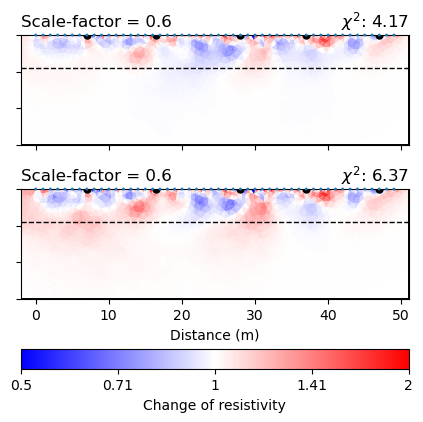

In [5]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(5,6))
plt.subplots_adjust(hspace=-0.5)
for nr, chi2, m, name in zip([0,1],[chi2_oT, chi2_wT], [mod, mod_Tcorr], ['withoutTcorr', 'withTcorr']):
    ratio = m[1] / m[0]
    bild2 = manager[0].showResult(model= ratio,coverage = manager[0].coverage(),
            cMin=1/2, cMax=2, cMap= 'bwr', ax= axs[nr], label = 'Change of resistivity', logScale= True)
    if nr < 1:
        cb = bild2[-1]
        cb.remove() 
        axs[nr].xaxis.set_ticklabels([])  # Unterdrückt die x-Achse Labels
    if nr == 1:
        axs[nr].set_xlabel('Distance (m)')
        
    axs[nr].yaxis.set_ticklabels([])  # Unterdrückt die y-Achse Labels
    axs[nr].set_title('$\chi^2$: '+ str(chi2[0]), loc = 'right')
    axs[nr].set_title('Scale-factor = '+ str(scalef), loc = 'left')
    tree_postions = [7, 16.5, 28, 37, 47]
    for x in tree_postions:
        axs[nr].plot(x, 0, '.', markersize=10, color='black')
    axs[nr].set_ylim(-15, 0)
    axs[nr].axhline(y=-4.5, color='k', linewidth = 1,linestyle='--')

fig.savefig('./Fig11/FTL_inversion.png' , bbox_inches = 'tight', dpi=300)
# neue Filterung, filter 10 % 